# Checkpoint Parameter Reader + HSI Visualization

本 notebook 用于：
1. 读取 checkpoint 对应实验参数。
2. 从 gaussian_model.best.pth.tar 或 gaussian_model.pth.tar 重建 HSI。
3. 构造伪 RGB，与 GT 对比并显示 error map。

说明：该模型依赖 CUDA (gsplat)，渲染单元需在 GPU 环境运行。


In [2]:
from pathlib import Path
import re
import math

import numpy as np
import scipy.io
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.decomposition import NMF

from gaussianimage_cholesky_unknown import GaussianImage_Cholesky_EA


ModuleNotFoundError: No module named 'gaussianimage_cholesky_unknown'

In [34]:
# ===== 用户配置 =====
CHECKPOINT_ROOT = Path('checkpoints_hsi/fitting')

# 请选择包含模型权重的实验目录（形如 ..._50000_15000_12）
EXPERIMENT_DIR = CHECKPOINT_ROOT / 'GaussianImage_Cholesky_nd_50000_10000_12'

# 可选: Salinas | Urban | JasperRidge | PaviaU
DATASET_NAME = 'Urban'

# True: gaussian_model.best.pth.tar, False: gaussian_model.pth.tar
USE_BEST = True

# 伪RGB波段，按 [blue, green, red] 传入
# None 时自动按总波段数取近似的 20% / 50% / 80% 波段
PSEUDO_RGB_BANDS = [20,30,40]

# NMF 初始化随机种子（需与训练保持一致）
NMF_RANDOM_STATE = 42


In [4]:
def get_dataset_rank(name: str) -> int:
    return 10 if name.lower() == 'jasperridge' else 12


def load_dataset(name: str):
    n = name.lower()
    if n == 'urban':
        dataset_name = 'Urban'
        I = scipy.io.loadmat('HSI/data/Urban_R162.mat')['Y'].astype(np.float32)
        for i in range(162):
            I[i, :] /= max(np.max(I[i, :]), 1e-8)
        I = I.reshape(162, 307, 307).transpose(2, 1, 0)

    elif n == 'salinas':
        dataset_name = 'Salinas'
        mat = scipy.io.loadmat('HSI/data/Salinas_crop.mat')
        key = 'salinas_corrected' if 'salinas_corrected' in mat else 'salinas'
        I = mat[key].astype(np.float32)
        I = np.clip(I, 0, None)
        for i in range(I.shape[2]):
            I[:, :, i] /= max(np.max(I[:, :, i]), 1e-8)

    elif n == 'jasperridge':
        dataset_name = 'JasperRidge'
        I = scipy.io.loadmat('HSI/data/jasperRidge2_R198.mat')['Y'].astype(np.float32)
        for i in range(198):
            I[i, :] /= max(np.max(I[i, :]), 1e-8)
        I = I.reshape(198, 100, 100).transpose(2, 1, 0)

    elif n == 'paviau':
        dataset_name = 'PaviaU'
        I = scipy.io.loadmat('HSI/data/PaviaU.mat')['paviaU'].astype(np.float32)
        for i in range(103):
            I[:, :, i] /= max(np.max(I[:, :, i]), 1e-8)
        I = I[-340:, :, :]

    else:
        raise ValueError(f'Unknown dataset: {name}')

    return dataset_name, I


def initialize_endmember(image_hwc: np.ndarray, rank: int, random_state: int = 42) -> np.ndarray:
    matrix = np.transpose(image_hwc, (2, 0, 1)).reshape(image_hwc.shape[2], -1)
    nmf = NMF(n_components=rank, init='random', random_state=random_state, max_iter=12000)
    return nmf.fit_transform(matrix).T.astype(np.float32)


def parse_experiment_params(exp_dir: Path) -> dict:
    params = {
        'Experiment': exp_dir.name,
        'Num_Points': None,
        'Max_Num_Points': None,
        'Rank': None,
        'Lora_Rank': None,
        'Gabor': None,
        'Prune_iter': None,
        'Add_iter': None,
    }
    m = re.match(r'^GaussianImage_Cholesky_nd_(\d+)_(\d+)(?:_(\d+))?$', exp_dir.name)
    if m:
        params['Max_Num_Points'] = int(m.group(1))
        params['Num_Points'] = int(m.group(2))
        if m.group(3) is not None:
            params['Rank'] = int(m.group(3))
    return params


def parse_last_metrics(train_txt: Path, dataset_name: str):
    if not train_txt.exists():
        return None
    pattern = re.compile(
        rf'^{re.escape(dataset_name)}:.*?Rank:\s*(\d+),\s*PSNR:([0-9.]+),\s*MS-SSIM:([0-9.]+),\s*SAM:([0-9.]+)',
        re.IGNORECASE,
    )
    last = None
    for line in train_txt.read_text(encoding='utf-8', errors='ignore').splitlines():
        mm = pattern.search(line.strip())
        if mm:
            last = {
                'Rank': int(mm.group(1)),
                'PSNR': float(mm.group(2)),
                'MS-SSIM': float(mm.group(3)),
                'SAM': float(mm.group(4)),
            }
    return last


def choose_bands(channels: int, bands=None):
    if bands is not None:
        return bands
    b = int(channels * 0.2)
    g = int(channels * 0.5)
    r = int(channels * 0.8)
    return [max(0, min(channels - 1, x)) for x in [b, g, r]]


def create_pseudorgb(image_hwc: np.ndarray, bands):
    blue = image_hwc[:, :, bands[0]]
    green = image_hwc[:, :, bands[1]]
    red = image_hwc[:, :, bands[2]]

    def norm(x):
        return (x - np.min(x)) / (np.max(x) - np.min(x) + 1e-8)

    return np.dstack([norm(red), norm(green), norm(blue)])


def rmse_map(gt_hwc: np.ndarray, pred_hwc: np.ndarray):
    return np.sqrt(np.mean((gt_hwc - pred_hwc) ** 2, axis=-1))


def sam_map(gt_hwc: np.ndarray, pred_hwc: np.ndarray, eps=1e-8):
    dot = np.sum(gt_hwc * pred_hwc, axis=-1)
    ng = np.linalg.norm(gt_hwc, axis=-1)
    npred = np.linalg.norm(pred_hwc, axis=-1)
    cosv = dot / (ng * npred + eps)
    cosv = np.clip(cosv, -1.0, 1.0)
    return np.degrees(np.arccos(cosv))


In [27]:
assert EXPERIMENT_DIR.exists(), f'Experiment dir not found: {EXPERIMENT_DIR}'
assert torch.cuda.is_available(), '需要 CUDA 才能运行 gsplat 渲染。'

dataset_name, gt_hwc = load_dataset(DATASET_NAME)
params = parse_experiment_params(EXPERIMENT_DIR)

if params['Rank'] is None:
    params['Rank'] = get_dataset_rank(dataset_name)

rank = int(params['Rank'])
num_points = params['Num_Points']

ckpt_name = 'gaussian_model.best.pth.tar' if USE_BEST else 'gaussian_model.pth.tar'
ckpt_path = EXPERIMENT_DIR / dataset_name / ckpt_name
assert ckpt_path.exists(), f'Checkpoint not found: {ckpt_path}'

H, W, C = gt_hwc.shape
gt_tensor = torch.tensor(gt_hwc).view(-1, H, W, C).permute(0, 3, 1, 2).contiguous().clamp(0, 1).to('cuda:0').half()

E = initialize_endmember(gt_hwc, rank=rank, random_state=NMF_RANDOM_STATE)

model = GaussianImage_Cholesky_EA(
    loss_type='L2',
    opt_type='adam',
    num_points=int(num_points),
    GT=gt_tensor,
    E=E,
    H=H,
    W=W,
    C=C,
    rank=rank,
    BLOCK_H=16,
    BLOCK_W=16,
    device=torch.device('cuda:0'),
    lr=5e-3,
    quantize=False,
).to('cuda:0')

state = torch.load(ckpt_path, map_location='cuda:0')
model.load_state_dict(state, strict=False)
model.eval()

with torch.no_grad():
    out = model.forward()
    A = out['render'].float()
    E_t = model.endmember.float()
    pred = (A @ E_t).view(-1, H, W, C).permute(0, 3, 1, 2).contiguous()

pred = pred.clamp(0, 1)
pred_hwc = pred[0].permute(1, 2, 0).detach().cpu().numpy()
gt_hwc = gt_tensor[0].permute(1, 2, 0).float().detach().cpu().numpy()

mse = F.mse_loss(pred.float(), gt_tensor.float()).item()
psnr = 10.0 * math.log10(1.0 / max(mse, 1e-12))
sam_mean_deg = np.mean(sam_map(gt_hwc, pred_hwc))

params['Dataset'] = dataset_name
params['Checkpoint'] = str(ckpt_path)
params['PSNR_recomputed'] = psnr
params['SAM_recomputed_deg'] = sam_mean_deg

train_txt = EXPERIMENT_DIR / 'train.txt'
metric_log = parse_last_metrics(train_txt, dataset_name)

print('===== Parsed Parameters =====')
for k in ['Experiment', 'Dataset', 'Num_Points', 'Max_Num_Points', 'Rank', 'Lora_Rank', 'Gabor', 'Prune_iter', 'Add_iter']:
    print(f'{k}: {params.get(k)}')

print('\n===== Recomputed Metrics =====')
print(f'PSNR: {psnr:.4f}')
print(f'SAM (deg): {sam_mean_deg:.4f}')

if metric_log is not None:
    print('\n===== Last Log Metrics (train.txt) =====')
    for kk, vv in metric_log.items():
        print(f'{kk}: {vv}')


E0 GPU memory usage: 0.0078125 MB
===== Parsed Parameters =====
Experiment: GaussianImage_Cholesky_nd_50000_10000_12
Dataset: Urban
Num_Points: 10000
Max_Num_Points: 50000
Rank: 12
Lora_Rank: None
Gabor: None
Prune_iter: None
Add_iter: None

===== Recomputed Metrics =====
PSNR: 35.9821
SAM (deg): 3.1103


/tmp/ipykernel_128382/864711036.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt_path, map_location='cuda:0')


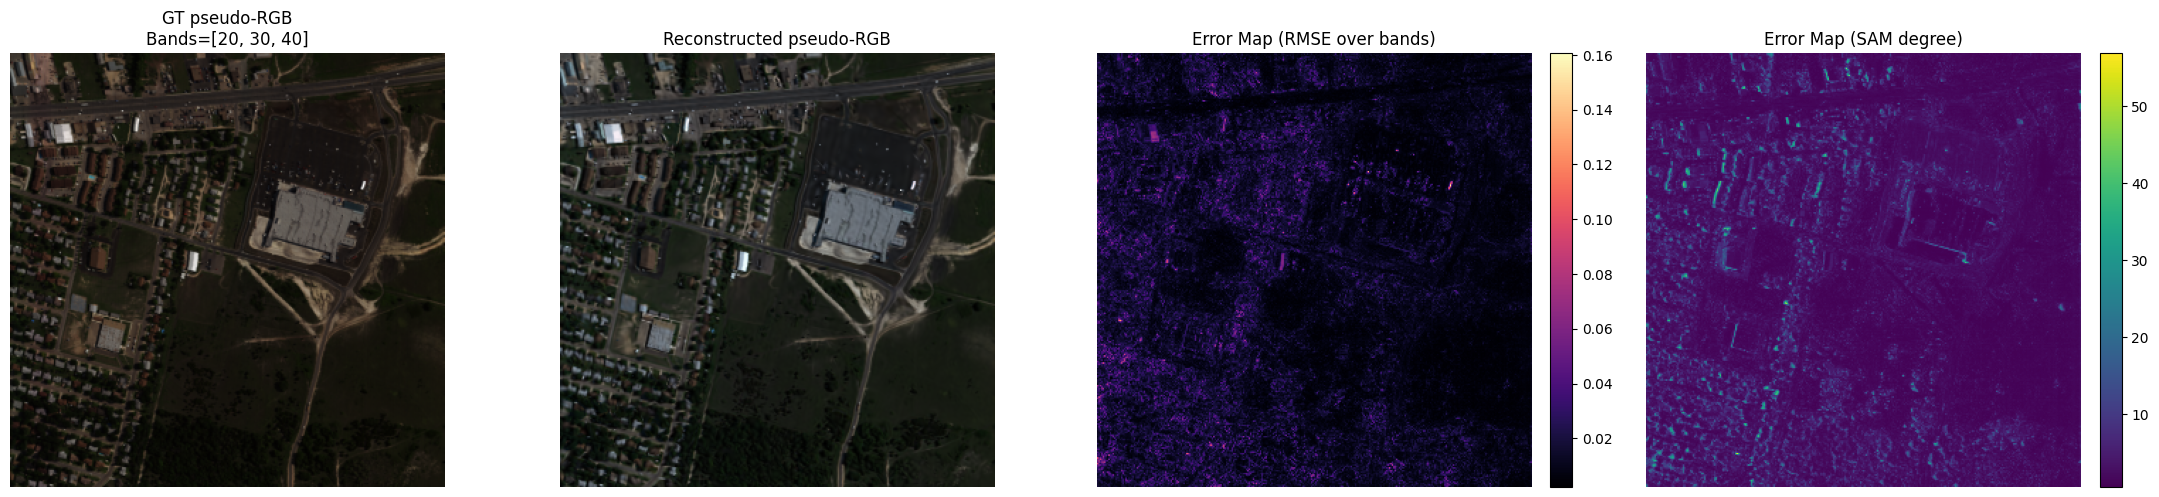

In [35]:
bands = choose_bands(gt_hwc.shape[2], PSEUDO_RGB_BANDS)
gt_rgb = create_pseudorgb(gt_hwc, bands)
pred_rgb = create_pseudorgb(pred_hwc, bands)
err_rmse = rmse_map(gt_hwc, pred_hwc)
err_sam = sam_map(gt_hwc, pred_hwc)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].imshow(gt_rgb)
axes[0].set_title(f'GT pseudo-RGB\nBands={bands}')
axes[0].axis('off')

axes[1].imshow(pred_rgb)
axes[1].set_title('Reconstructed pseudo-RGB')
axes[1].axis('off')

im2 = axes[2].imshow(err_rmse, cmap='magma')
axes[2].set_title('Error Map (RMSE over bands)')
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

im3 = axes[3].imshow(err_sam, cmap='viridis')
axes[3].set_title('Error Map (SAM degree)')
axes[3].axis('off')
plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


In [1]:

# ===== 小区域 Error Map 对比（用于与 Gabor 高频细节对比）=====
# 调整下方参数选取感兴趣区域
CROP_Y = 130      # 裁剪起始行（像素）
CROP_X = 110      # 裁剪起始列（像素）
CROP_H = 50       # 裁剪高度（像素）
CROP_W = 50       # 裁剪宽度（像素）

# ---- 裁剪 ----
def crop(arr2d_or_3d, y, x, h, w):
    return arr2d_or_3d[y:y+h, x:x+w]

H_img, W_img = gt_hwc.shape[:2]
y0 = max(0, min(CROP_Y, H_img - 1))
x0 = max(0, min(CROP_X, W_img - 1))
ch = max(1, min(CROP_H, H_img - y0))
cw = max(1, min(CROP_W, W_img - x0))

gt_crop     = crop(gt_hwc,   y0, x0, ch, cw)
pred_crop   = crop(pred_hwc, y0, x0, ch, cw)
rmse_crop   = crop(err_rmse, y0, x0, ch, cw)
sam_crop    = crop(err_sam,  y0, x0, ch, cw)

gt_rgb_crop   = create_pseudorgb(gt_crop,   bands)
pred_rgb_crop = create_pseudorgb(pred_crop, bands)

# ---- 在全局图中标记裁剪框 ----
from matplotlib.patches import Rectangle

fig0, axes0 = plt.subplots(1, 2, figsize=(12, 5))
for ax, img, title in zip(axes0, [gt_rgb, pred_rgb], ['GT (with crop box)', 'Reconstructed (with crop box)']):
    ax.imshow(img)
    ax.add_patch(Rectangle((x0, y0), cw, ch, linewidth=2, edgecolor='red', facecolor='none'))
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

# ---- 裁剪区域可视化 ----
fig1, axes1 = plt.subplots(1, 4, figsize=(20, 5))
fig1.suptitle(f'Crop Region  y={y0}:{y0+ch},  x={x0}:{x0+cw}', fontsize=12)

axes1[0].imshow(gt_rgb_crop);   axes1[0].set_title('GT crop pseudo-RGB');   axes1[0].axis('off')
axes1[1].imshow(pred_rgb_crop); axes1[1].set_title('Recon crop pseudo-RGB'); axes1[1].axis('off')

im_r = axes1[2].imshow(rmse_crop, cmap='magma',  vmin=err_rmse.min(), vmax=err_rmse.max())
axes1[2].set_title('Crop Error Map (RMSE)'); axes1[2].axis('off')
plt.colorbar(im_r, ax=axes1[2], fraction=0.046, pad=0.04)

im_s = axes1[3].imshow(sam_crop,  cmap='viridis', vmin=err_sam.min(),  vmax=err_sam.max())
axes1[3].set_title('Crop Error Map (SAM°)'); axes1[3].axis('off')
plt.colorbar(im_s, ax=axes1[3], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


NameError: name 'gt_hwc' is not defined

In [ ]:
# 可选：保存可视化结果
save_dir = Path('checkpoints_hsi/visualizations')
save_dir.mkdir(parents=True, exist_ok=True)
save_path = save_dir / f'{EXPERIMENT_DIR.name}_{dataset_name}_viz.png'

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(gt_rgb); axes[0].set_title('GT pseudo-RGB'); axes[0].axis('off')
axes[1].imshow(pred_rgb); axes[1].set_title('Reconstructed pseudo-RGB'); axes[1].axis('off')
im = axes[2].imshow(err_rmse, cmap='magma'); axes[2].set_title('Error Map (RMSE)'); axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(save_path, dpi=180, bbox_inches='tight')
plt.close(fig)
print(f'Saved visualization to: {save_path}')
